# Sensor Data EDA

Exploratory analysis of sensor readings (light, humidity, temperature, pressure).

**Expected sampling interval:** 5 minutes. We'll check for gaps.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)
pd.set_option("display.max_columns", None)

## 1. Load the data

In [2]:
# Update the path to your CSV file
df = pd.read_csv("sensors_data.csv", parse_dates=["recorded_at"])
df = df.sort_values("recorded_at").reset_index(drop=True)

print(f"Rows: {len(df):,}")
print(f"Date range: {df['recorded_at'].min()}  ->  {df['recorded_at'].max()}")
print(f"Total span: {df['recorded_at'].max() - df['recorded_at'].min()}")
df.head()

Rows: 10,498
Date range: 2026-02-12 17:30:00  ->  2026-05-31 09:20:00
Total span: 107 days 15:50:00


,id,recorded_at,light,humidity,temperature,pressure
0,1,2026-02-12 17:30:00,440,100.0,19.7,1014.6
1,2,2026-02-12 17:35:00,546,100.0,19.6,1014.6
2,3,2026-02-12 17:40:00,549,100.0,19.6,1014.5
3,4,2026-02-12 17:45:00,528,100.0,19.6,1014.4
4,5,2026-02-12 17:50:00,568,100.0,19.5,1014.3


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10498 entries, 0 to 10497
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id           10498 non-null  int64         
 1   recorded_at  10498 non-null  datetime64[us]
 2   light        10498 non-null  int64         
 3   humidity     10498 non-null  float64       
 4   temperature  10498 non-null  float64       
 5   pressure     10498 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(2)
memory usage: 492.2 KB


## 2. Summary statistics

In [4]:
df.describe()

,id,recorded_at,light,humidity,temperature,pressure
count,10498.000000,10498,10498.000000,10498.000000,10498.000000,10498.000000
mean,5276.126024,2026-04-13 17:15:48.270337,617.494189,74.462736,22.983492,1013.827758
min,1.000000,2026-02-12 17:30:00,68.000000,22.400000,15.600000,1003.600000
25%,2657.250000,2026-02-22 23:46:15,218.000000,58.500000,19.100000,1010.800000
50%,5281.500000,2026-05-09 08:42:30,568.000000,71.500000,22.600000,1012.700000
75%,7905.750000,2026-05-21 16:08:45,1024.000000,100.000000,26.600000,1016.100000
max,10530.000000,2026-05-31 09:20:00,1024.000000,100.000000,34.700000,1027.900000
std,3038.414787,NaN,391.299424,21.527027,4.666586,4.888092


## 3. Missing values in columns

In [5]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2)
})
missing

,missing_count,missing_pct
id,0,0.0
recorded_at,0,0.0
light,0,0.0
humidity,0,0.0
temperature,0,0.0
pressure,0,0.0


### Duplicate timestamps

Same timestamp appearing more than once. Worth knowing about - might indicate sensor double-reporting or pipeline issues. We don't drop them here, just report.

In [6]:
dup_mask = df.duplicated(subset="recorded_at", keep=False)
n_dup_timestamps = df["recorded_at"].duplicated().sum()

print(f"Duplicate timestamps: {n_dup_timestamps}")
print(f"Rows involved: {dup_mask.sum()}  ({dup_mask.mean() * 100:.2f}% of data)")

# Peek at a few to see if values are identical or differ
if dup_mask.any():
    print("\nSample of duplicated rows:")
    display(df[dup_mask].sort_values("recorded_at").head(10))

Duplicate timestamps: 1
Rows involved: 2  (0.02% of data)

Sample of duplicated rows:


,id,recorded_at,light,humidity,temperature,pressure
4253,4286,2026-05-05 21:50:00,1024,59.8,21.9,1010.2
4254,4287,2026-05-05 21:50:00,1024,59.8,21.9,1010.2


## 4. Missing timestamps

Data should arrive every 5 minutes. Let's find the gaps.

In [7]:
EXPECTED_INTERVAL = pd.Timedelta(minutes=5)

# Build the full expected timeline
full_range = pd.date_range(
    start=df["recorded_at"].min(),
    end=df["recorded_at"].max(),
    freq=EXPECTED_INTERVAL
)

expected_count = len(full_range)
actual_count = len(df)
missing_count = expected_count - actual_count

print(f"Expected readings: {expected_count:,}")
print(f"Actual readings:   {actual_count:,}")
print(f"Missing readings:  {missing_count:,}  ({missing_count / expected_count * 100:.2f}%)")

Expected readings: 31,007
Actual readings:   10,498
Missing readings:  20,509  (66.14%)


In [8]:
# Find the specific missing timestamps
missing_timestamps = full_range.difference(df["recorded_at"])
print(f"Number of missing timestamps: {len(missing_timestamps):,}")
pd.Series(missing_timestamps).tail(20)

Number of missing timestamps: 20,681


20661   2026-05-30 07:05:00
20662   2026-05-30 07:10:00
20663   2026-05-30 07:15:00
20664   2026-05-30 07:20:00
20665   2026-05-30 07:25:00
20666   2026-05-30 07:30:00
20667   2026-05-30 07:35:00
20668   2026-05-30 07:40:00
20669   2026-05-30 07:45:00
20670   2026-05-30 07:50:00
20671   2026-05-30 07:55:00
20672   2026-05-30 08:00:00
20673   2026-05-30 08:10:00
20674   2026-05-30 08:15:00
20675   2026-05-30 08:20:00
20676   2026-05-30 08:25:00
20677   2026-05-30 08:30:00
20678   2026-05-30 08:35:00
20679   2026-05-30 08:40:00
20680   2026-05-30 08:45:00
dtype: datetime64[us]

### Gap analysis - how long were the outages?

In [9]:
# Time difference between consecutive readings
df["time_diff"] = df["recorded_at"].diff()

# Any gap larger than the expected 5 minutes is a problem
gaps = df[df["time_diff"] > EXPECTED_INTERVAL].copy()
gaps["gap_minutes"] = gaps["time_diff"].dt.total_seconds() / 60
gaps["missing_readings"] = (gaps["gap_minutes"] / 5 - 1).astype(int)

print(f"Number of gaps: {len(gaps)}")
print(f"Longest gap: {gaps['time_diff'].max()}")
print(f"Total missing readings from gaps: {gaps['missing_readings'].sum():,}")

gaps[["recorded_at", "time_diff", "gap_minutes", "missing_readings"]].sort_values("gap_minutes", ascending=False).head(15)

Number of gaps: 182
Longest gap: 66 days 06:20:00
Total missing readings from gaps: 20,508


,recorded_at,time_diff,gap_minutes,missing_readings
4245,2026-05-05 21:10:00,66 days 06:20:00,95420.000000,19083
6114,2026-05-15 13:30:00,1 days 01:34:58,1534.966667,305
1763,2026-02-19 15:50:00,0 days 19:20:00,1160.000000,231
5965,2026-05-11 21:30:02,0 days 01:05:02,65.033333,12
2600,2026-02-22 15:00:02,0 days 00:40:00,40.000000,7
2609,2026-02-22 18:30:02,0 days 00:40:00,40.000000,7
2618,2026-02-22 23:15:02,0 days 00:40:00,40.000000,7
2617,2026-02-22 22:35:02,0 days 00:40:00,40.000000,7
2615,2026-02-22 21:15:02,0 days 00:40:00,40.000000,7
2610,2026-02-22 19:10:02,0 days 00:40:00,40.000000,7


### Missing data by day

In [10]:
# Use a deduplicated copy locally so reindex works.
# We don't modify df itself - EDA should observe, not clean.
df_unique = df.drop_duplicates(subset="recorded_at", keep="first")
df_indexed = df_unique.set_index("recorded_at").reindex(full_range)
df_indexed.index.name = "recorded_at"

missing_by_day = (
    df_indexed["id"].isna()
    .resample("D")
    .agg(["sum", "count"])
    .rename(columns={"sum": "missing", "count": "expected"})
)
missing_by_day["missing_pct"] = (missing_by_day["missing"] / missing_by_day["expected"] * 100).round(1)
missing_by_day = missing_by_day[missing_by_day["missing"] > 0].sort_values("missing", ascending=False)

print(f"Days with missing data: {len(missing_by_day)}")
missing_by_day.tail(15)

Days with missing data: 82


,missing,expected,missing_pct
recorded_at,,,
2026-05-12,275,288,95.5
2026-05-05,254,288,88.2
2026-02-19,190,288,66.0
2026-05-15,162,288,56.2
2026-02-22,116,288,40.3
2026-02-28,110,288,38.2
2026-05-29,103,288,35.8
2026-05-30,102,288,35.4
2026-02-18,42,288,14.6


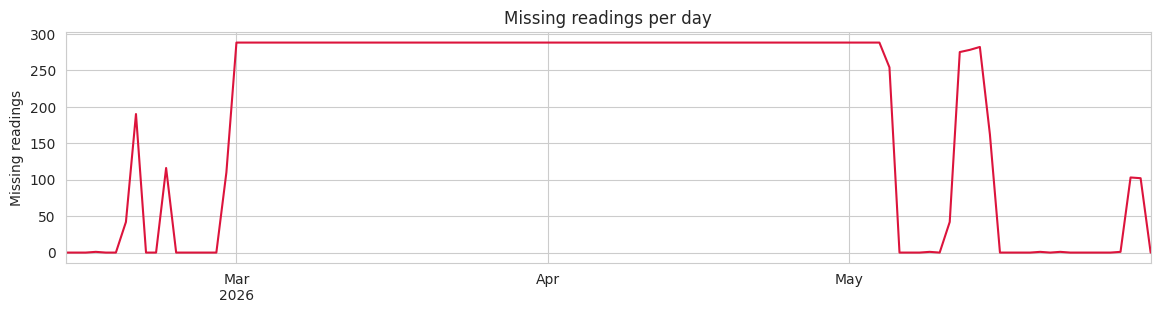

In [11]:
# Visualize missing data over time
fig, ax = plt.subplots(figsize=(14, 3))
df_indexed["id"].isna().resample("D").sum().plot(ax=ax, color="crimson")
ax.set_title("Missing readings per day")
ax.set_ylabel("Missing readings")
ax.set_xlabel("")
plt.show()

## 5. Time series - what the data looks like

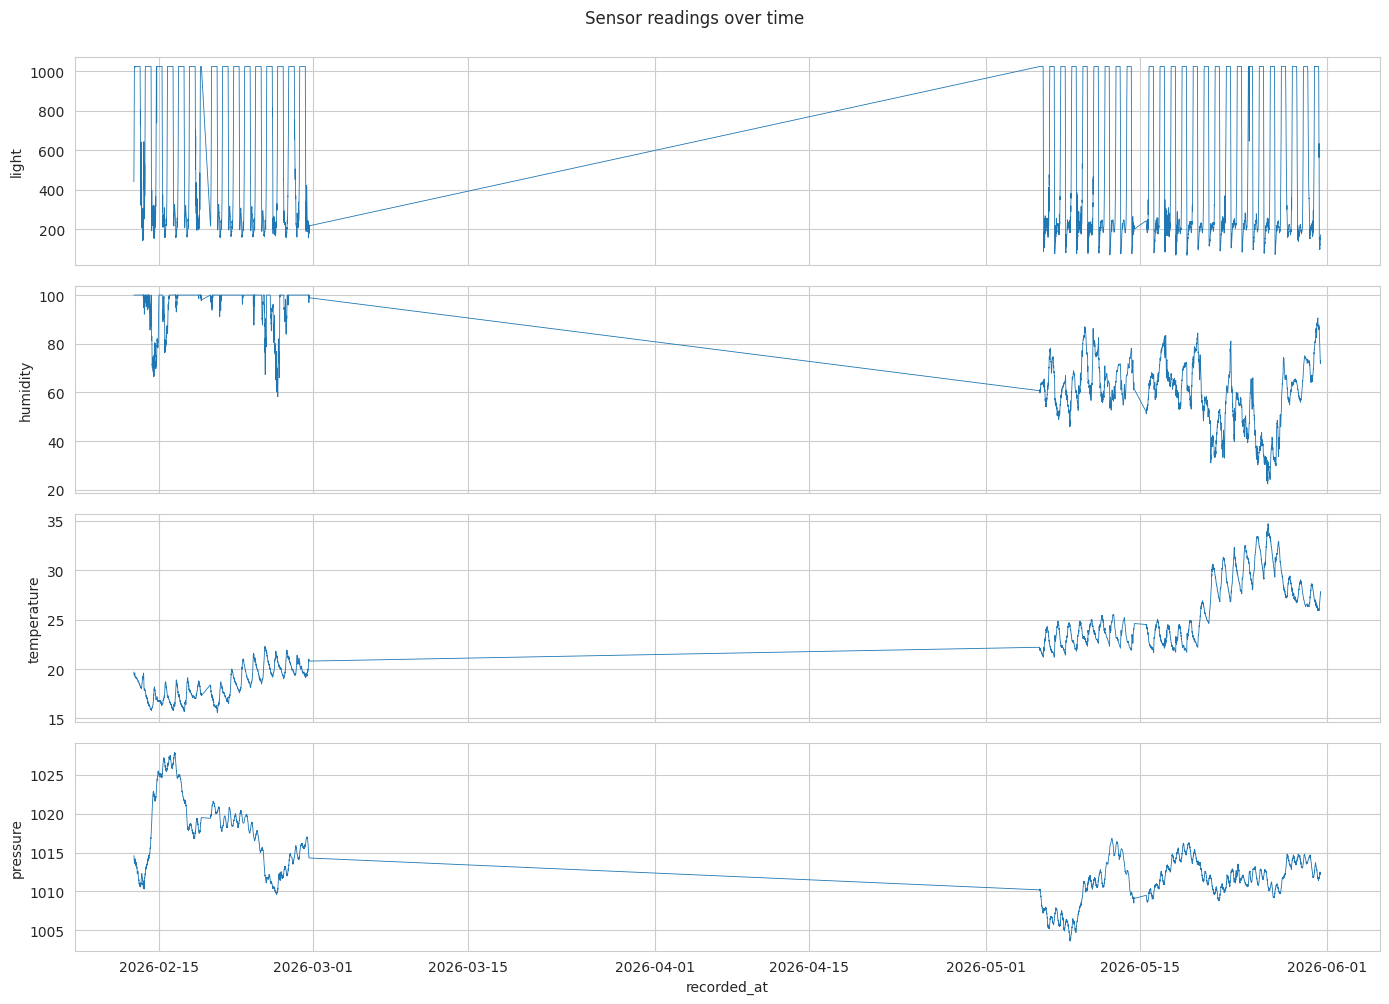

In [12]:
sensors = ["light", "humidity", "temperature", "pressure"]

fig, axes = plt.subplots(len(sensors), 1, figsize=(14, 10), sharex=True)
for ax, col in zip(axes, sensors):
    ax.plot(df["recorded_at"], df[col], linewidth=0.6)
    ax.set_ylabel(col)
axes[-1].set_xlabel("recorded_at")
plt.suptitle("Sensor readings over time", y=1.00)
plt.tight_layout()
plt.show()

## 6. Distributions

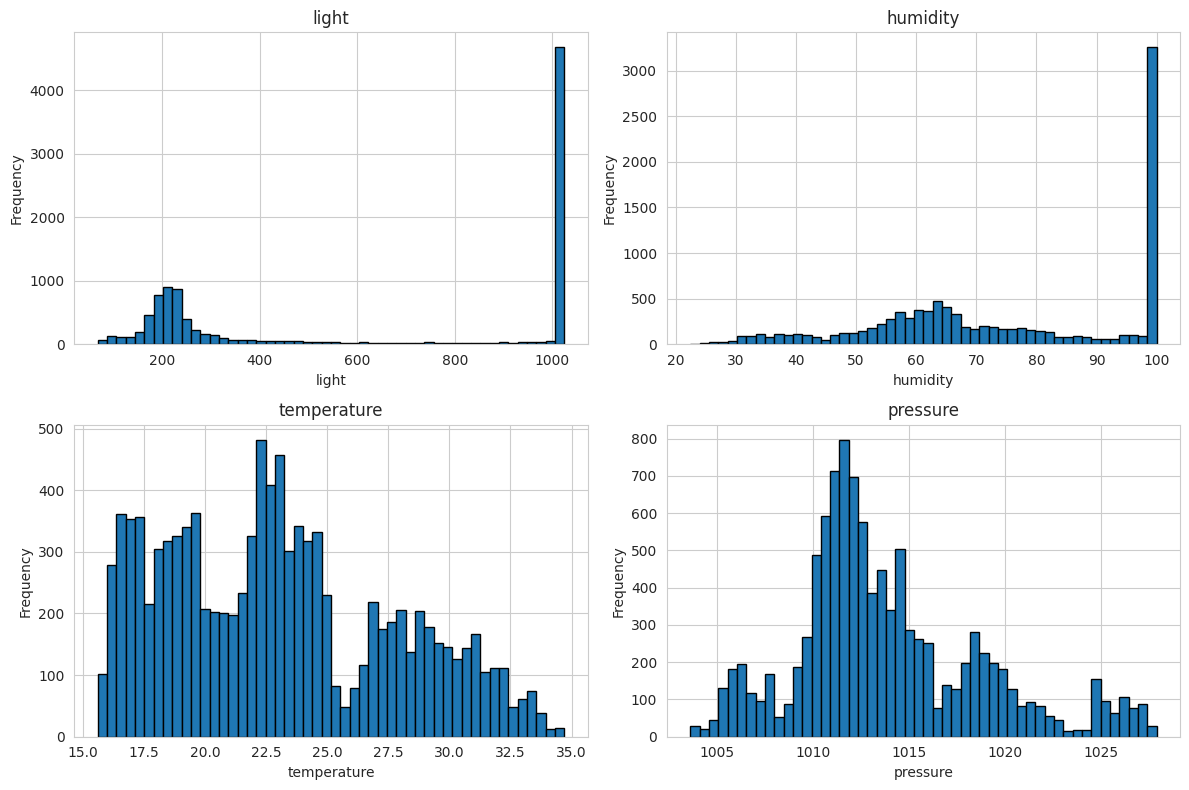

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), sensors):
    df[col].plot.hist(bins=50, ax=ax, edgecolor="black")
    ax.set_title(col)
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

## 7. Correlations between sensors

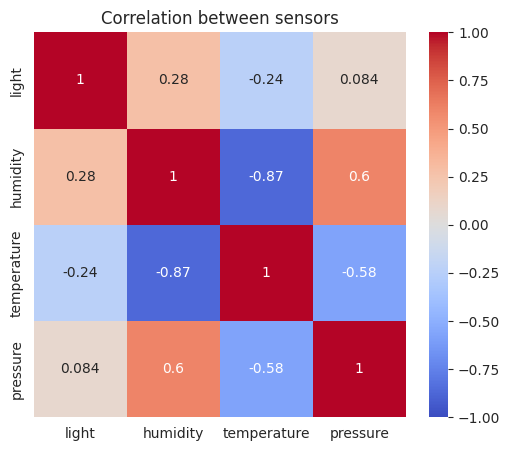

In [14]:
corr = df[sensors].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation between sensors")
plt.show()

## 8. Outlier check

In [15]:
bounds = {
    "temperature": (-5, 45),    # °C — adjust for your climate
    "humidity":    (0, 100),     # % — physically capped
    "pressure":    (950, 1050),  # hPa — sea-level range
    "light":       (0, 1024),  # depends on your sensor's max
}

for col, (lo, hi) in bounds.items():
    n_bad = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f"{col}: {n_bad} readings outside [{lo}, {hi}]")

temperature: 0 readings outside [-5, 45]
humidity: 0 readings outside [0, 100]
pressure: 0 readings outside [950, 1050]
light: 0 readings outside [0, 1024]
